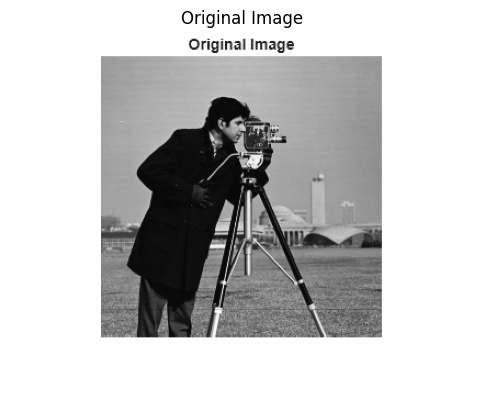

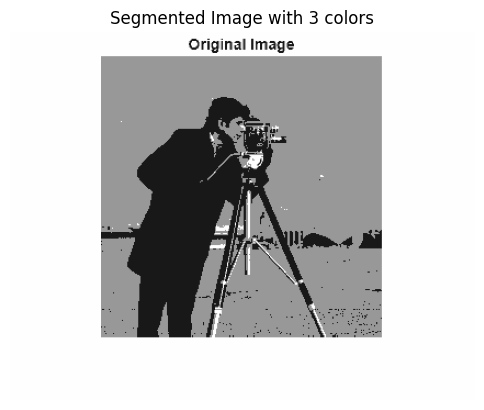

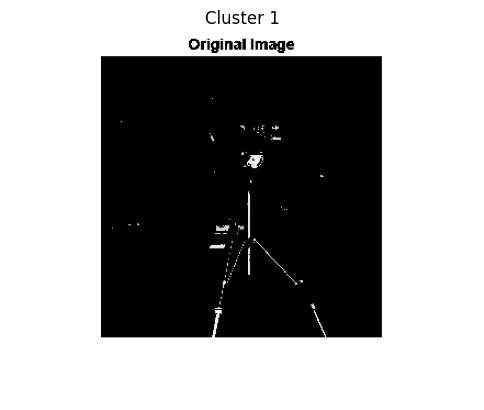

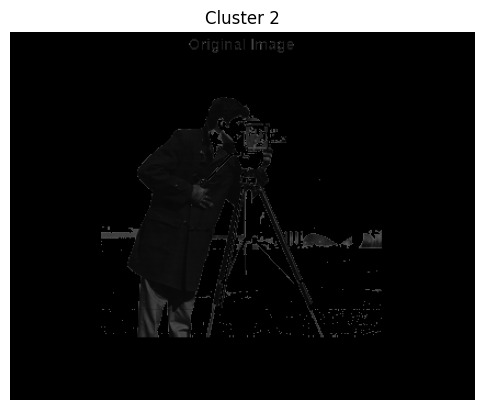

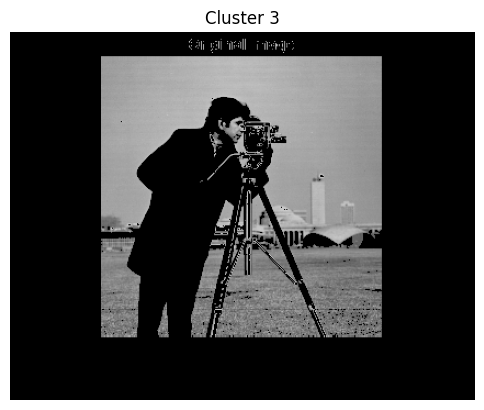

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from sklearn.cluster import KMeans

# ---- Step 1: Read image ----
image = mpimg.imread("myimage.png")  # Your local image file

# If image has alpha channel (RGBA), drop it
if image.shape[-1] == 4:
    image = image[:, :, :3]

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# ---- Step 2: Reshape into (num_pixels, 3) ----
pixels = image.reshape(-1, 3)

# ---- Step 3: K-Means clustering ----
k = 3  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixels)

# ---- Step 4: Map each pixel to centroid color ----
segmented_pixels = kmeans.cluster_centers_[kmeans.labels_]
segmented_image = segmented_pixels.reshape(image.shape)

# ---- Step 5: Show segmented image ----
plt.figure(figsize=(6,6))
plt.imshow(segmented_image)
plt.title(f"Segmented Image with {k} colors")
plt.axis("off")
plt.show()

# ---- Step 6: Show each segment separately ----
labels = kmeans.labels_.reshape(image.shape[0], image.shape[1])

for i in range(k):
    mask = (labels == i)
    cluster_img = np.zeros_like(image)
    cluster_img[mask] = image[mask]

    plt.figure(figsize=(6,6))
    plt.imshow(cluster_img)
    plt.title(f"Cluster {i+1}")
    plt.axis("off")
    plt.show()


